# Financial Performance Analysis — NVIDIA vs Intel
## A Data-Driven Story (2009–2023)

**Autor:** Rafael Reghine Munhoz  
**Dataset:** Financial Statements of Major Companies — Kaggle  
**Objetivo:** Analisar e comparar a trajetória financeira de NVIDIA e Intel ao longo de 15 anos, identificando os fatores que levaram à inversão de posições no mercado de semicondutores.




**Instalação de Dependências**

In [1]:
!pip install prophet -q
!pip install scikit-learn -q

import sklearn
print(f'Sklearn: {sklearn.__version__}')
print('Dependências instaladas!')

✅ Sklearn: 1.6.1
✅ Dependências instaladas!
⚠️  Runtime → Restart Runtime → execute a partir da Célula 2


**Upoad Dataset**

In [2]:
from google.colab import files
import io

print('Selecione o arquivo Financial_Statements.csv:')
uploaded = files.upload()

for fname in uploaded.keys():
    print(f'Carregado: {fname} ({len(uploaded[fname])/1024:.1f} KB)')

Selecione o arquivo Financial_Statements.csv:


Saving Financial Statements.csv to Financial Statements.csv
Carregado: Financial Statements.csv (24.0 KB)


**Bibliotecas**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from prophet import Prophet

# Paleta de cores
COR_NVDA  = '#76b900'  # Verde NVIDIA
COR_INTC  = '#0071c5'  # Azul Intel
BG        = '#f8f9fa'

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

pd.set_option('display.float_format', '{:.2f}'.format)
print(f'NumPy: {np.__version__}')
print('Todas as bibliotecas importadas!')

✅ NumPy: 2.0.2
✅ Todas as bibliotecas importadas!


**Preparação dos Dados**

In [4]:
# Carregar dataset
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))
df.columns = df.columns.str.strip()

# Filtrar empresas
nvda = df[df['Company'] == 'NVDA'].sort_values('Year').reset_index(drop=True)
intc = df[df['Company'] == 'INTC'].sort_values('Year').reset_index(drop=True)

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Empresas: {sorted(df["Company"].unique())}')
print(f'Período:  {df["Year"].min()} — {df["Year"].max()}')
print(f'\n NVIDIA: {len(nvda)} anos de dados')
print(f' Intel:  {len(intc)} anos de dados')

✅ Dataset carregado: 161 linhas x 23 colunas
   Empresas: ['AAPL', 'AIG', 'AMZN', 'BCS', 'GOOG', 'INTC', 'MCD', 'MSFT', 'NVDA', 'PCG', 'PYPL', 'SHLDQ']
   Período:  2009 — 2023

📊 NVIDIA: 15 anos de dados
📊 Intel:  14 anos de dados


In [5]:
# Adicionar métricas calculadas
def enrich(df_co):
    df_co = df_co.copy()
    df_co['Revenue_YoY']    = df_co['Revenue'].pct_change() * 100
    df_co['NetIncome_YoY']  = df_co['Net Income'].pct_change() * 100
    df_co['MarketCap_YoY']  = df_co['Market Cap(in B USD)'].pct_change() * 100
    df_co['Revenue_B']      = df_co['Revenue'] / 1000
    df_co['NetIncome_B']    = df_co['Net Income'] / 1000
    return df_co

nvda = enrich(nvda)
intc = enrich(intc)

print('Métricas calculadas')
print('\nNVIDIA — últimos 5 anos:')
print(nvda.tail(5)[['Year','Revenue_B','Net Income','Market Cap(in B USD)','Net Profit Margin','ROE']].to_string(index=False))

Métricas calculadas

NVIDIA — últimos 5 anos:
 Year  Revenue_B  Net Income  Market Cap(in B USD)  Net Profit Margin   ROE
 2019      11.72     4141.00                144.00              35.34 44.33
 2020      10.92     2796.00                323.24              25.61 22.91
 2021      16.68     4332.00                735.86              25.98 25.64
 2022      26.91     9752.00                359.50              36.23 36.65
 2023      26.97     4368.00               1000.35              16.19 19.76


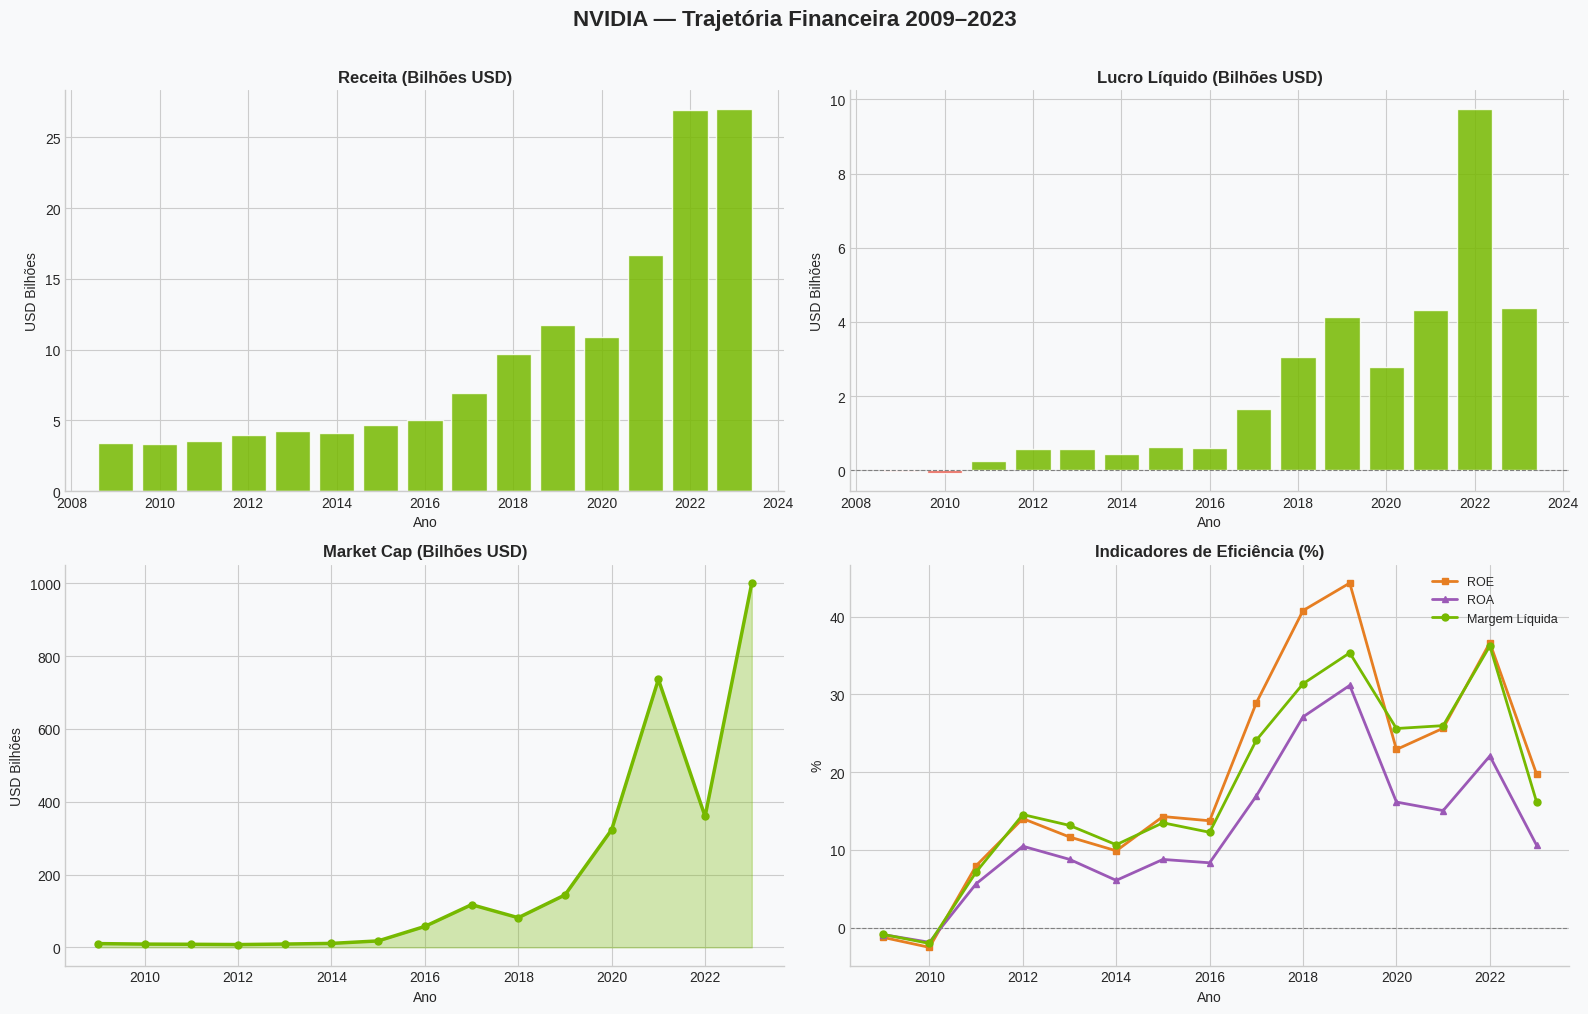

nvda_analysis.png salvo


In [6]:
# ── NVIDIA: Receita, Lucro e Market Cap ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('NVIDIA — Trajetória Financeira 2009–2023', fontsize=16, fontweight='bold', y=1.01)

# 1. Receita
ax = axes[0, 0]
ax.set_facecolor(BG)
ax.bar(nvda['Year'], nvda['Revenue_B'], color=COR_NVDA, alpha=0.85, edgecolor='white')
ax.set_title('Receita (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 2. Lucro Líquido
ax = axes[0, 1]
ax.set_facecolor(BG)
cores_lucro = [COR_NVDA if v >= 0 else '#e74c3c' for v in nvda['NetIncome_B']]
ax.bar(nvda['Year'], nvda['NetIncome_B'], color=cores_lucro, alpha=0.85, edgecolor='white')
ax.set_title('Lucro Líquido (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('USD Bilhões')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 3. Market Cap
ax = axes[1, 0]
ax.set_facecolor(BG)
ax.fill_between(nvda['Year'], nvda['Market Cap(in B USD)'], alpha=0.3, color=COR_NVDA)
ax.plot(nvda['Year'], nvda['Market Cap(in B USD)'], color=COR_NVDA, linewidth=2.5, marker='o', markersize=5)
ax.set_title('Market Cap (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Indicadores de Eficiência
ax = axes[1, 1]
ax.set_facecolor(BG)
ax.plot(nvda['Year'], nvda['ROE'], color='#e67e22', linewidth=2, marker='s', markersize=5, label='ROE')
ax.plot(nvda['Year'], nvda['ROA'], color='#9b59b6', linewidth=2, marker='^', markersize=5, label='ROA')
ax.plot(nvda['Year'], nvda['Net Profit Margin'], color=COR_NVDA, linewidth=2, marker='o', markersize=5, label='Margem Líquida')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Indicadores de Eficiência (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('%')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('nvda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('nvda_analysis.png salvo')

**Análise Individual: NVIDIA**

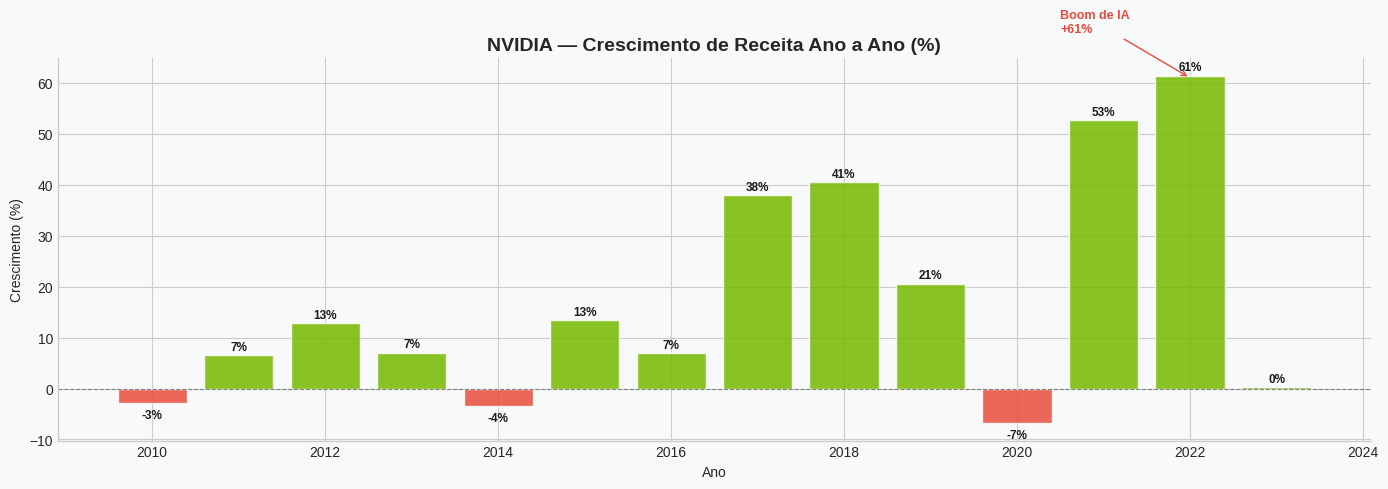

💾 nvda_yoy.png salvo


In [7]:
# NVIDIA — Crescimento YoY
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

yoy = nvda.dropna(subset=['Revenue_YoY'])
cores_yoy = [COR_NVDA if v >= 0 else '#e74c3c' for v in yoy['Revenue_YoY']]
bars = ax.bar(yoy['Year'], yoy['Revenue_YoY'], color=cores_yoy, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, yoy['Revenue_YoY']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (1 if val >= 0 else -3),
            f'{val:.0f}%', ha='center', fontsize=8.5,
            fontweight='600', color='#1c1c1c')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('NVIDIA — Crescimento de Receita Ano a Ano (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Crescimento (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Anotação do boom de IA
ax.annotate('Boom de IA\n+61%', xy=(2022, 61), xytext=(2020.5, 70),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=9, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig('nvda_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 nvda_yoy.png salvo')

In [8]:
# NVIDIA — Insights
print('=' * 60)
print('INSIGHTS — NVIDIA')
print('=' * 60)

print(f'\nReceita 2009: US$ {nvda[nvda["Year"]==2009]["Revenue_B"].values[0]:.1f}B')
print(f'Receita 2023: US$ {nvda[nvda["Year"]==2023]["Revenue_B"].values[0]:.1f}B')
crescimento_total = ((nvda[nvda['Year']==2023]['Revenue'].values[0] / nvda[nvda['Year']==2009]['Revenue'].values[0]) - 1) * 100
print(f'Crescimento total: +{crescimento_total:.0f}%')

print(f'\nMarket Cap 2009:  US$ {nvda[nvda["Year"]==2009]["Market Cap(in B USD)"].values[0]:.1f}B')
print(f'Market Cap 2023:  US$ {nvda[nvda["Year"]==2023]["Market Cap(in B USD)"].values[0]:.1f}B')

print(f'\nMaior crescimento YoY: {nvda["Revenue_YoY"].max():.1f}% (ano: {nvda.loc[nvda["Revenue_YoY"].idxmax(), "Year"]})')
print(f'Melhor margem líquida: {nvda["Net Profit Margin"].max():.1f}% (ano: {nvda.loc[nvda["Net Profit Margin"].idxmax(), "Year"]})')
print(f'Melhor ROE:            {nvda["ROE"].max():.1f}% (ano: {nvda.loc[nvda["ROE"].idxmax(), "Year"]})')

INSIGHTS — NVIDIA

Receita 2009: US$ 3.4B
Receita 2023: US$ 27.0B
Crescimento total: +688%

Market Cap 2009:  US$ 10.4B
Market Cap 2023:  US$ 1000.4B

Maior crescimento YoY: 61.4% (ano: 2022)
Melhor margem líquida: 36.2% (ano: 2022)
Melhor ROE:            44.3% (ano: 2019)


**Análise Individual: Intel**

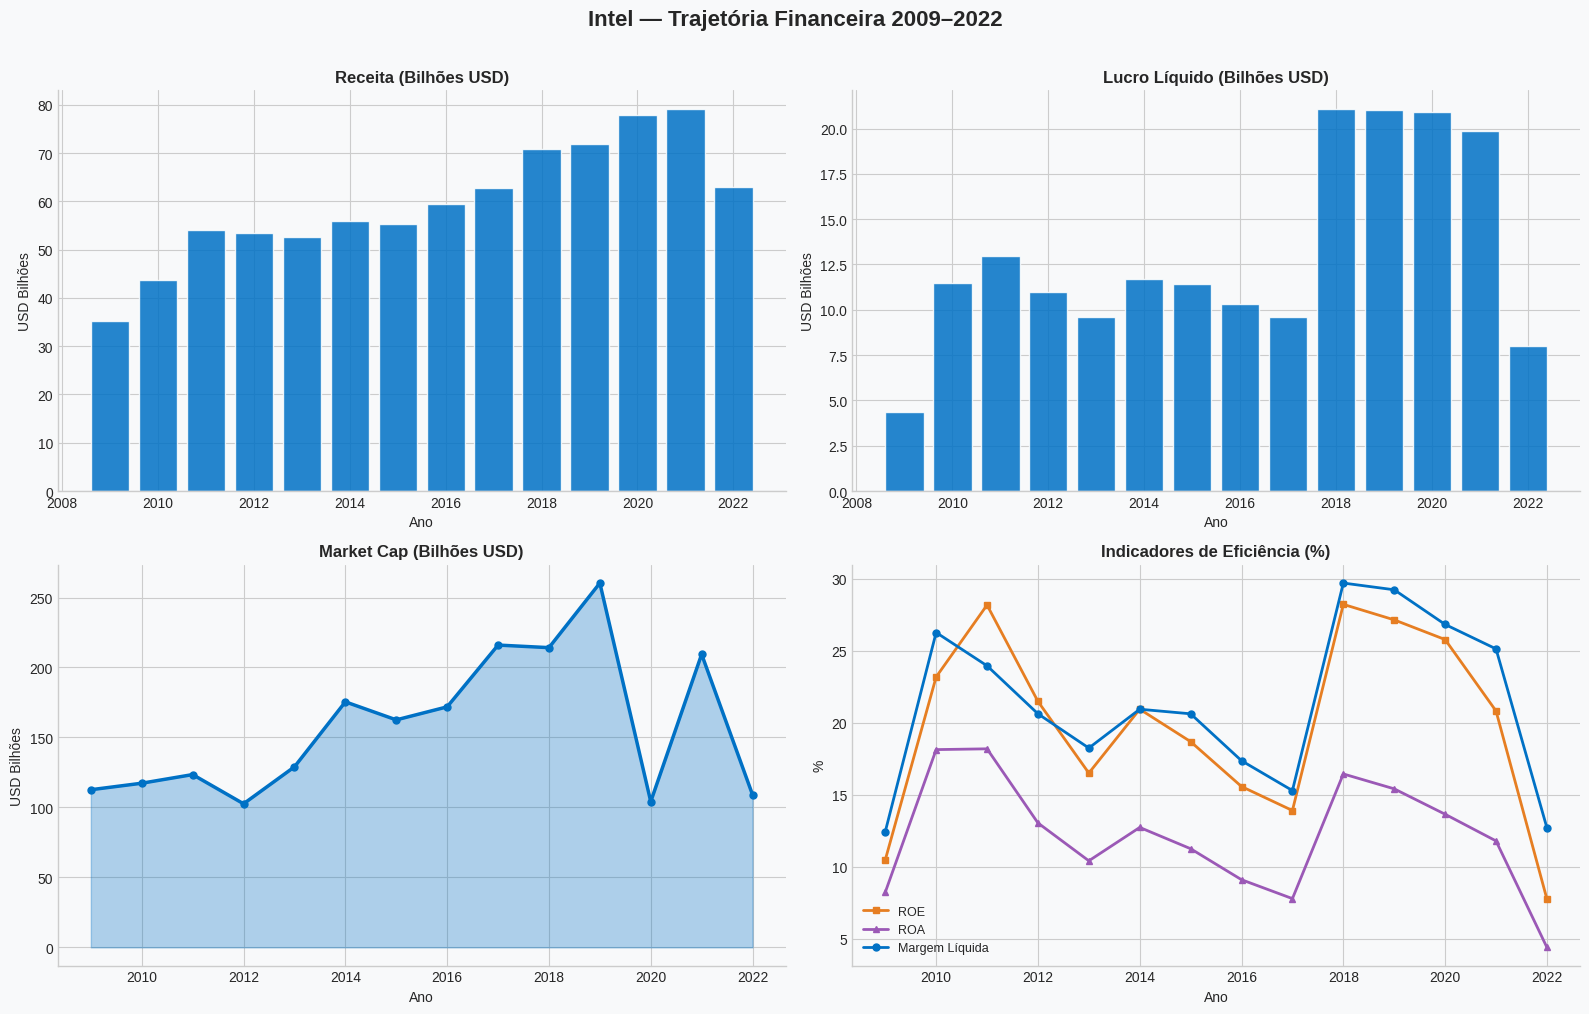

💾 intc_analysis.png salvo


In [9]:
# ── INTEL: Receita, Lucro e Market Cap ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Intel — Trajetória Financeira 2009–2022', fontsize=16, fontweight='bold', y=1.01)

# 1. Receita
ax = axes[0, 0]
ax.set_facecolor(BG)
ax.bar(intc['Year'], intc['Revenue']/1000, color=COR_INTC, alpha=0.85, edgecolor='white')
ax.set_title('Receita (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 2. Lucro Líquido
ax = axes[0, 1]
ax.set_facecolor(BG)
ax.bar(intc['Year'], intc['Net Income']/1000, color=COR_INTC, alpha=0.85, edgecolor='white')
ax.set_title('Lucro Líquido (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 3. Market Cap
ax = axes[1, 0]
ax.set_facecolor(BG)
ax.fill_between(intc['Year'], intc['Market Cap(in B USD)'], alpha=0.3, color=COR_INTC)
ax.plot(intc['Year'], intc['Market Cap(in B USD)'], color=COR_INTC, linewidth=2.5, marker='o', markersize=5)
ax.set_title('Market Cap (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Indicadores de Eficiência
ax = axes[1, 1]
ax.set_facecolor(BG)
ax.plot(intc['Year'], intc['ROE'], color='#e67e22', linewidth=2, marker='s', markersize=5, label='ROE')
ax.plot(intc['Year'], intc['ROA'], color='#9b59b6', linewidth=2, marker='^', markersize=5, label='ROA')
ax.plot(intc['Year'], intc['Net Profit Margin'], color=COR_INTC, linewidth=2, marker='o', markersize=5, label='Margem Líquida')
ax.set_title('Indicadores de Eficiência (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('%')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('intc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('intc_analysis.png salvo')

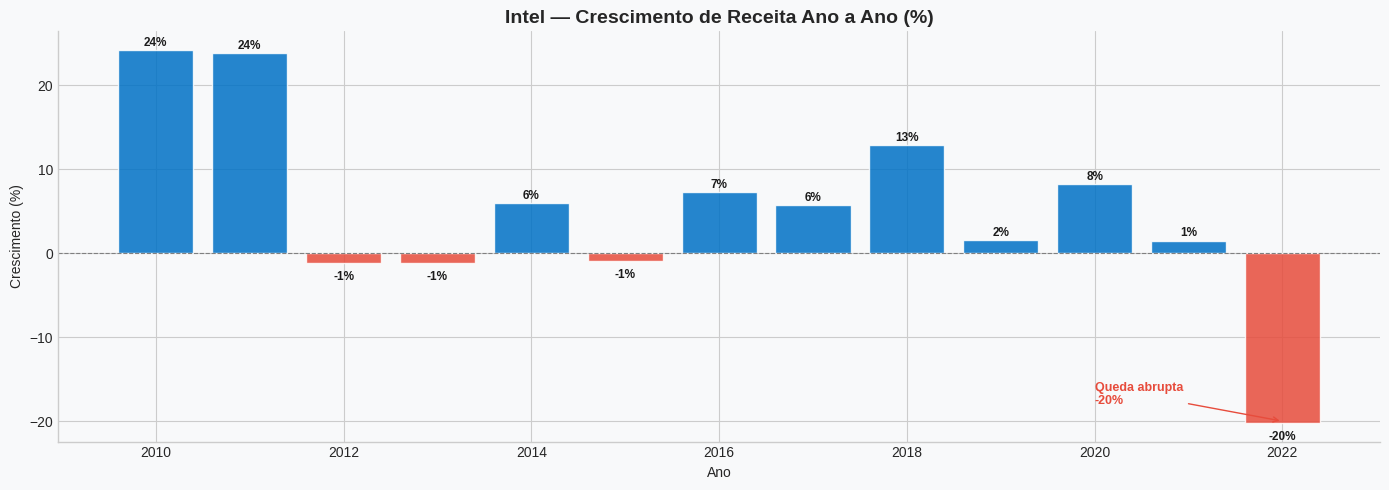

intc_yoy.png salvo


In [11]:
# Intel — Crescimento YoY
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

yoy_i = intc.dropna(subset=['Revenue_YoY'])
cores_yoy_i = [COR_INTC if v >= 0 else '#e74c3c' for v in yoy_i['Revenue_YoY']]
bars = ax.bar(yoy_i['Year'], yoy_i['Revenue_YoY'], color=cores_yoy_i, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, yoy_i['Revenue_YoY']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.5 if val >= 0 else -2),
            f'{val:.0f}%', ha='center', fontsize=8.5,
            fontweight='600', color='#1c1c1c')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Intel — Crescimento de Receita Ano a Ano (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Crescimento (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('Queda abrupta\n-20%', xy=(2022, -20), xytext=(2020, -18),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=9, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig('intc_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print('intc_yoy.png salvo')

In [12]:
# Intel — Insights
print('=' * 60)
print('INSIGHTS — INTEL')
print('=' * 60)

print(f'\nReceita 2009: US$ {intc[intc["Year"]==2009]["Revenue"].values[0]/1000:.1f}B')
print(f'Receita 2022: US$ {intc[intc["Year"]==2022]["Revenue"].values[0]/1000:.1f}B')
crescimento_intc = ((intc[intc['Year']==2022]['Revenue'].values[0] / intc[intc['Year']==2009]['Revenue'].values[0]) - 1) * 100
print(f'Crescimento total 2009-2022: +{crescimento_intc:.0f}%')

print(f'\nMarket Cap 2009:  US$ {intc[intc["Year"]==2009]["Market Cap(in B USD)"].values[0]:.1f}B')
print(f'Market Cap 2022:  US$ {intc[intc["Year"]==2022]["Market Cap(in B USD)"].values[0]:.1f}B')

print(f'\nMaior crescimento YoY: {intc["Revenue_YoY"].max():.1f}% (ano: {intc.loc[intc["Revenue_YoY"].idxmax(), "Year"]})')
print(f'Pior queda YoY:        {intc["Revenue_YoY"].min():.1f}% (ano: {intc.loc[intc["Revenue_YoY"].idxmin(), "Year"]})')
print(f'Melhor margem líquida: {intc["Net Profit Margin"].max():.1f}% (ano: {intc.loc[intc["Net Profit Margin"].idxmax(), "Year"]})')

INSIGHTS — INTEL

Receita 2009: US$ 35.1B
Receita 2022: US$ 63.1B
Crescimento total 2009-2022: +80%

Market Cap 2009:  US$ 112.7B
Market Cap 2022:  US$ 109.1B

Maior crescimento YoY: 24.2% (ano: 2010)
Pior queda YoY:        -20.2% (ano: 2022)
Melhor margem líquida: 29.7% (ano: 2018)


**Comparação NVIDIA vs Intel**

In [13]:
# Alinhar anos em comum
anos_comuns = sorted(set(nvda['Year']) & set(intc['Year']))
nvda_c = nvda[nvda['Year'].isin(anos_comuns)].reset_index(drop=True)
intc_c = intc[intc['Year'].isin(anos_comuns)].reset_index(drop=True)

print(f'Anos em comum: {anos_comuns}')

Anos em comum: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


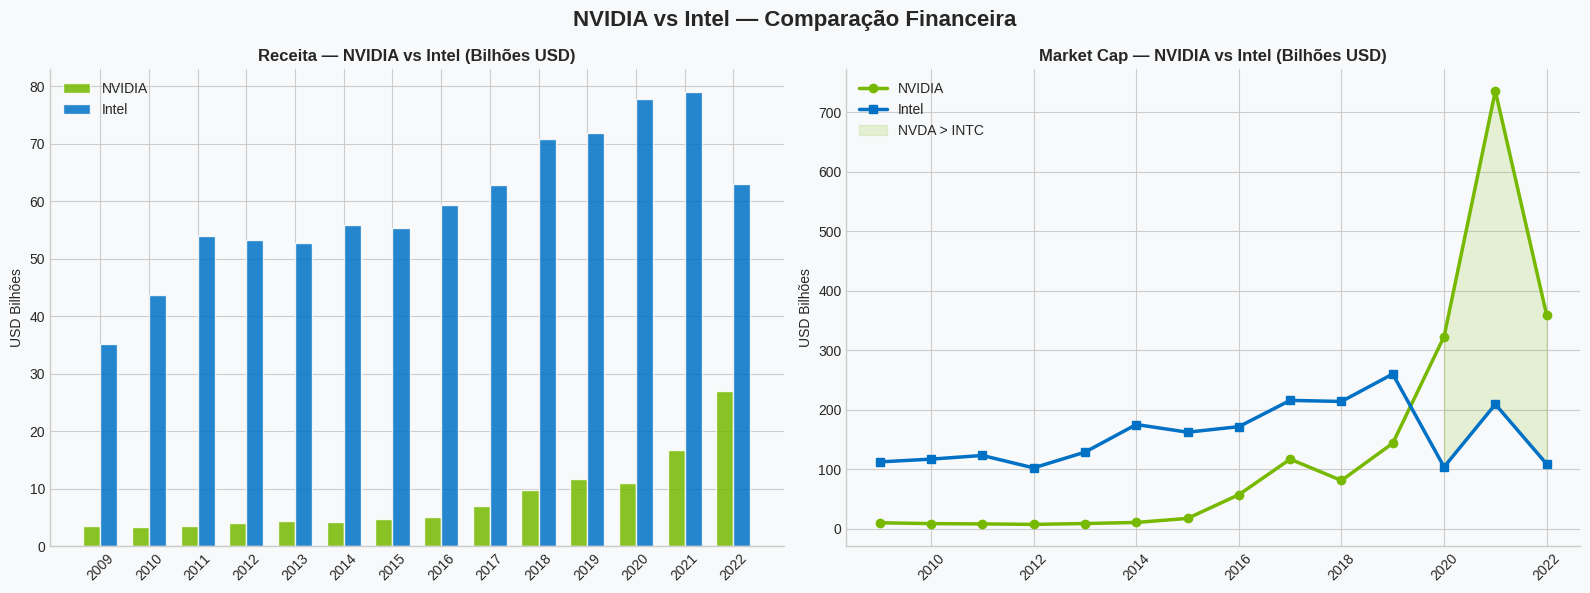

💾 comparacao_receita_marketcap.png salvo


In [14]:
# Comparação — Receita e Market Cap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('NVIDIA vs Intel — Comparação Financeira', fontsize=16, fontweight='bold')

x     = np.arange(len(anos_comuns))
width = 0.35

# Receita lado a lado
ax = axes[0]
ax.set_facecolor(BG)
ax.bar(x - width/2, nvda_c['Revenue_B'], width, label='NVIDIA', color=COR_NVDA, alpha=0.85, edgecolor='white')
ax.bar(x + width/2, intc_c['Revenue']/1000, width, label='Intel', color=COR_INTC, alpha=0.85, edgecolor='white')
ax.set_title('Receita — NVIDIA vs Intel (Bilhões USD)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(anos_comuns, rotation=45)
ax.legend(fontsize=10)
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Market Cap — linha
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(anos_comuns, nvda_c['Market Cap(in B USD)'], color=COR_NVDA, linewidth=2.5,
        marker='o', markersize=6, label='NVIDIA')
ax.plot(anos_comuns, intc_c['Market Cap(in B USD)'], color=COR_INTC, linewidth=2.5,
        marker='s', markersize=6, label='Intel')
ax.fill_between(anos_comuns, nvda_c['Market Cap(in B USD)'], intc_c['Market Cap(in B USD)'],
                where=nvda_c['Market Cap(in B USD)'].values > intc_c['Market Cap(in B USD)'].values,
                alpha=0.15, color=COR_NVDA, label='NVDA > INTC')
ax.set_title('Market Cap — NVIDIA vs Intel (Bilhões USD)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylabel('USD Bilhões')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('comparacao_receita_marketcap.png', dpi=150, bbox_inches='tight')
plt.show()
print('comparacao_receita_marketcap.png salvo')

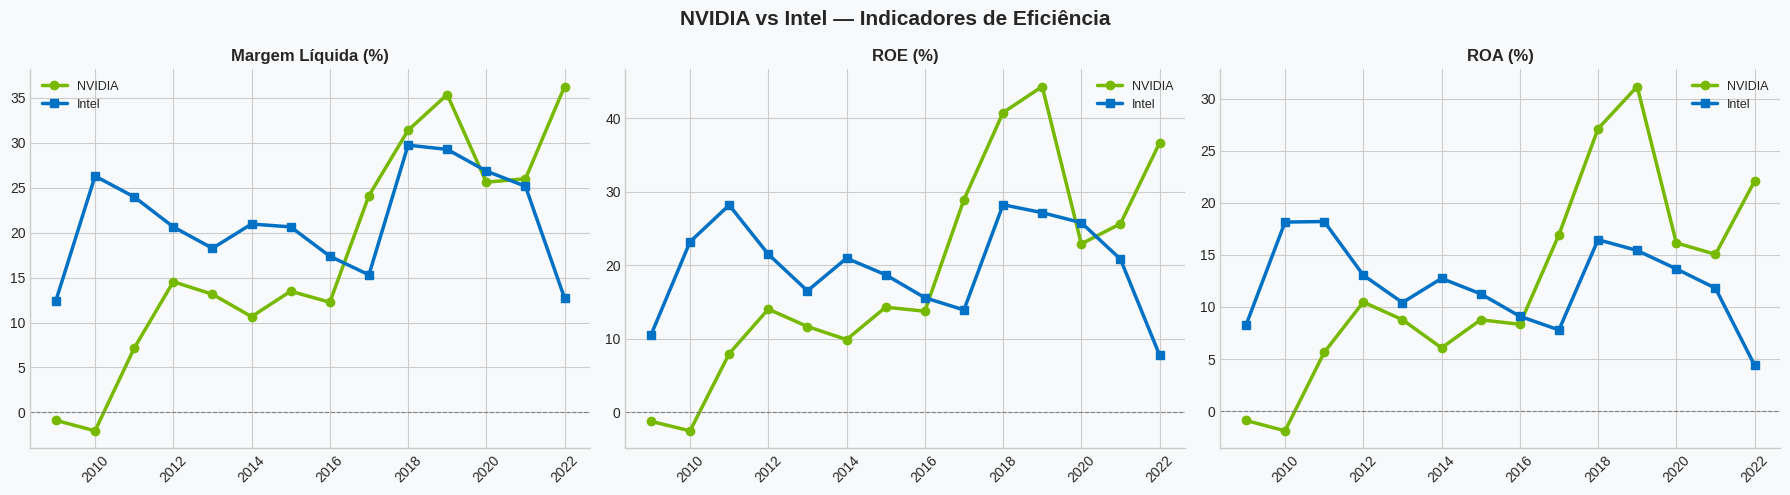

💾 comparacao_indicadores.png salvo


In [15]:
# Comparação — Margem, ROE e ROA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('NVIDIA vs Intel — Indicadores de Eficiência', fontsize=15, fontweight='bold')

metricas = [
    ('Net Profit Margin', 'Margem Líquida (%)'),
    ('ROE',               'ROE (%)'),
    ('ROA',               'ROA (%)')
]

for ax, (col, titulo) in zip(axes, metricas):
    ax.set_facecolor(BG)
    ax.plot(anos_comuns, nvda_c[col], color=COR_NVDA, linewidth=2.5,
            marker='o', markersize=6, label='NVIDIA')
    ax.plot(anos_comuns, intc_c[col], color=COR_INTC, linewidth=2.5,
            marker='s', markersize=6, label='Intel')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('comparacao_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 comparacao_indicadores.png salvo')

In [16]:
# Ranking comparativo — quem vence em cada métrica
metricas_rank = ['Revenue', 'Net Income', 'Market Cap(in B USD)',
                 'Net Profit Margin', 'ROE', 'ROA', 'ROI', 'EBITDA']

nvda_med = nvda_c[metricas_rank].mean()
intc_med = intc_c[metricas_rank].mean()

rank_df = pd.DataFrame({
    'Métrica': metricas_rank,
    'NVIDIA':  nvda_med.values,
    'Intel':   intc_med.values
})
rank_df['Vencedor'] = rank_df.apply(
    lambda r: 'NVIDIA' if r['NVIDIA'] > r['Intel'] else 'Intel', axis=1
)

print('\n Ranking — Médias do período em comum:')
print(rank_df.to_string(index=False))
print(f'\nNVIDIA vence em: {(rank_df["Vencedor"]=="NVIDIA").sum()} métricas')
print(f'Intel   vence em: {(rank_df["Vencedor"]=="Intel").sum()} métricas')


 Ranking — Médias do período em comum:
             Métrica  NVIDIA    Intel Vencedor
             Revenue 8231.55 59637.79    Intel
          Net Income 2051.27 13094.50    Intel
Market Cap(in B USD)  135.14   157.73    Intel
   Net Profit Margin   17.64    21.39    Intel
                 ROE   19.07    19.91    Intel
                 ROA   12.41    12.19   NVIDIA
                 ROI   15.45    15.82    Intel
              EBITDA 2483.55 24180.00    Intel

NVIDIA vence em: 1 métricas
Intel   vence em: 7 métricas


**Visão Geral: Todas as Empresas**

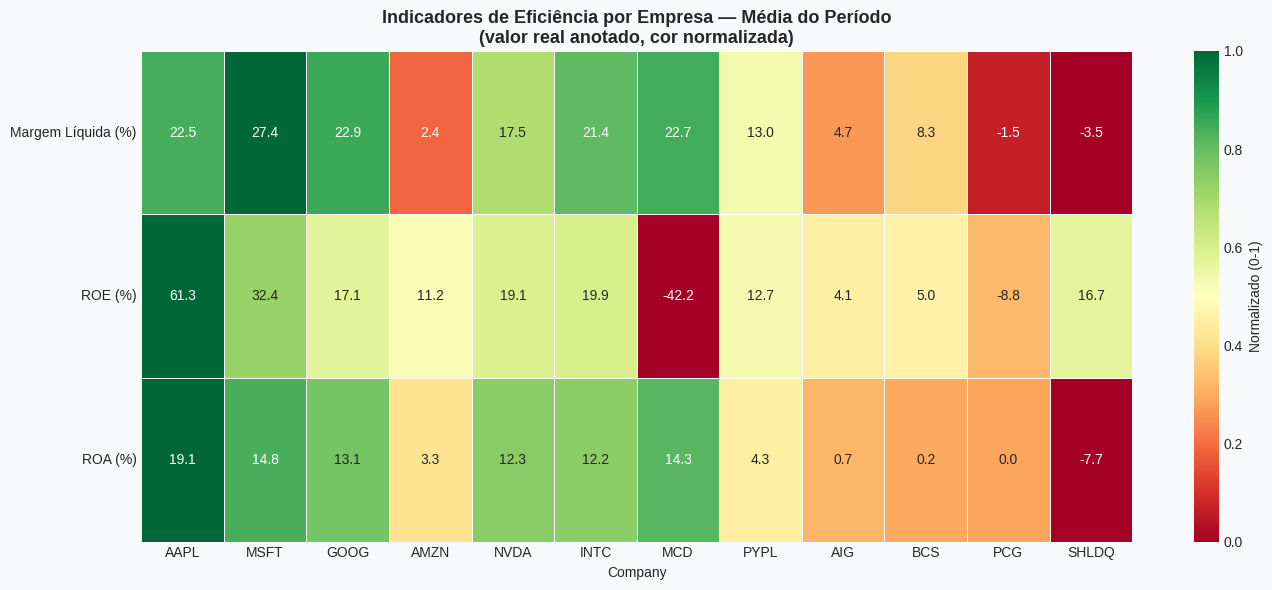

💾 heatmap_empresas.png salvo


In [17]:
# Médias por empresa
df_media = df.groupby('Company').agg(
    Revenue_Media   = ('Revenue', 'mean'),
    NetIncome_Media = ('Net Income', 'mean'),
    MarketCap_Media = ('Market Cap(in B USD)', 'mean'),
    Margem_Media    = ('Net Profit Margin', 'mean'),
    ROE_Media       = ('ROE', 'mean'),
    ROA_Media       = ('ROA', 'mean')
).reset_index().sort_values('MarketCap_Media', ascending=False)

# Heatmap de indicadores
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)

cols_hm  = ['Margem_Media', 'ROE_Media', 'ROA_Media']
hm_data  = df_media.set_index('Company')[cols_hm]
hm_norm  = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min())

sns.heatmap(hm_norm.T, annot=hm_data.T.round(1), fmt='.1f',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalizado (0-1)'})
ax.set_title('Indicadores de Eficiência por Empresa — Média do Período\n(valor real anotado, cor normalizada)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(['Margem Líquida (%)', 'ROE (%)', 'ROA (%)'], rotation=0)

plt.tight_layout()
plt.savefig('heatmap_empresas.png', dpi=150, bbox_inches='tight')
plt.show()
print('heatmap_empresas.png salvo')

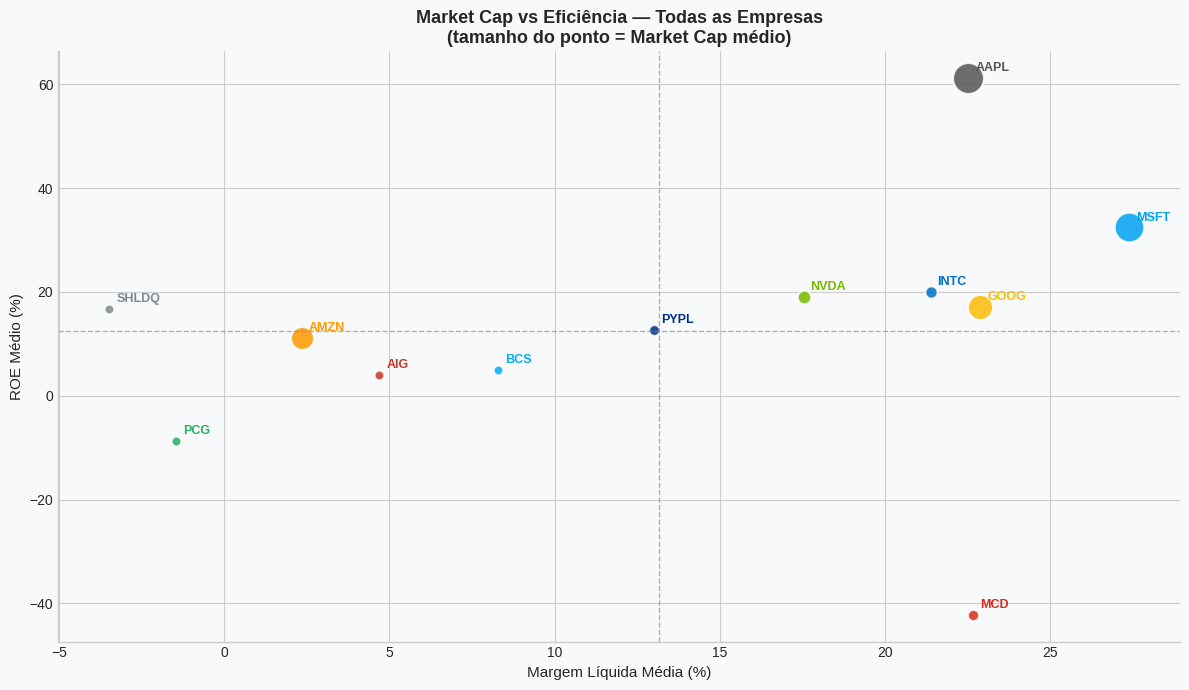

scatter_empresas.png salvo


In [19]:
# Scatter — Market Cap vs Margem Líquida
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

cores_empresa = {
    'NVDA': COR_NVDA, 'INTC': COR_INTC, 'AAPL': '#555555',
    'MSFT': '#00a1f1', 'GOOG': '#fbbc05', 'AMZN': '#ff9900',
    'PYPL': '#003087', 'MCD':  '#da291c', 'AIG':  '#c0392b',
    'BCS':  '#00aeef', 'PCG':  '#27ae60', 'SHLDQ':'#7f8c8d'
}

for _, row in df_media.iterrows():
    company = row['Company']
    cor = cores_empresa.get(company, '#aaa')
    size = max(row['MarketCap_Media'] * 0.5, 50)
    ax.scatter(row['Margem_Media'], row['ROE_Media'],
               s=size, color=cor, alpha=0.85, edgecolors='white', linewidth=1.5)
    ax.annotate(company,
                xy=(row['Margem_Media'], row['ROE_Media']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='600', color=cor)

ax.axhline(df_media['ROE_Media'].mean(), color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(df_media['Margem_Media'].mean(), color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Margem Líquida Média (%)', fontsize=11)
ax.set_ylabel('ROE Médio (%)', fontsize=11)
ax.set_title('Market Cap vs Eficiência — Todas as Empresas\n(tamanho do ponto = Market Cap médio)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scatter_empresas.png', dpi=150, bbox_inches='tight')
plt.show()
print('scatter_empresas.png salvo')

**Machine Learning: Forecast com Prophet**

INFO:prophet:n_changepoints greater than number of observations. Using 11.


Calculando forecast NVIDIA...


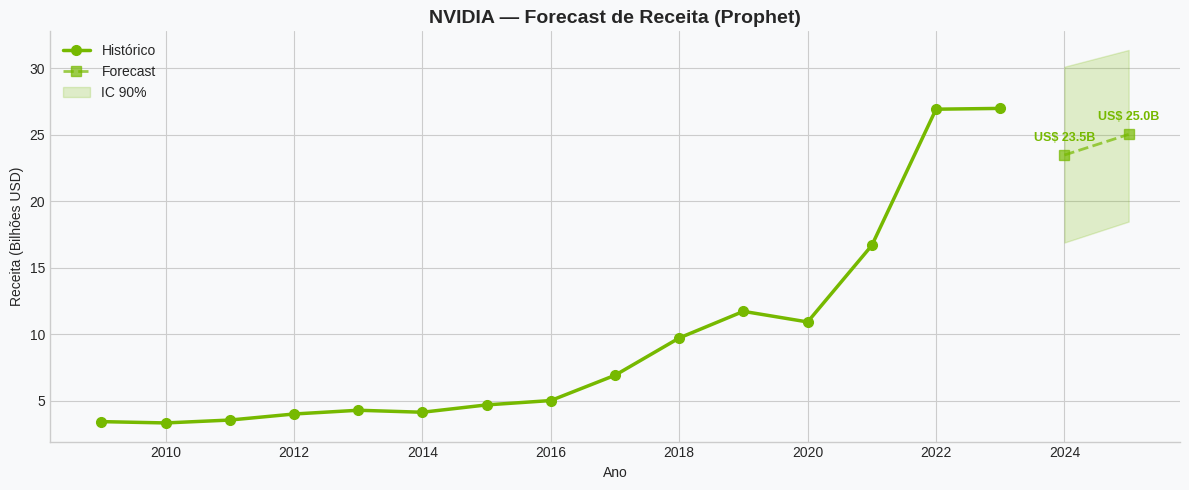

INFO:prophet:n_changepoints greater than number of observations. Using 10.


💾 forecast_nvidia.png salvo

 Calculando forecast Intel...


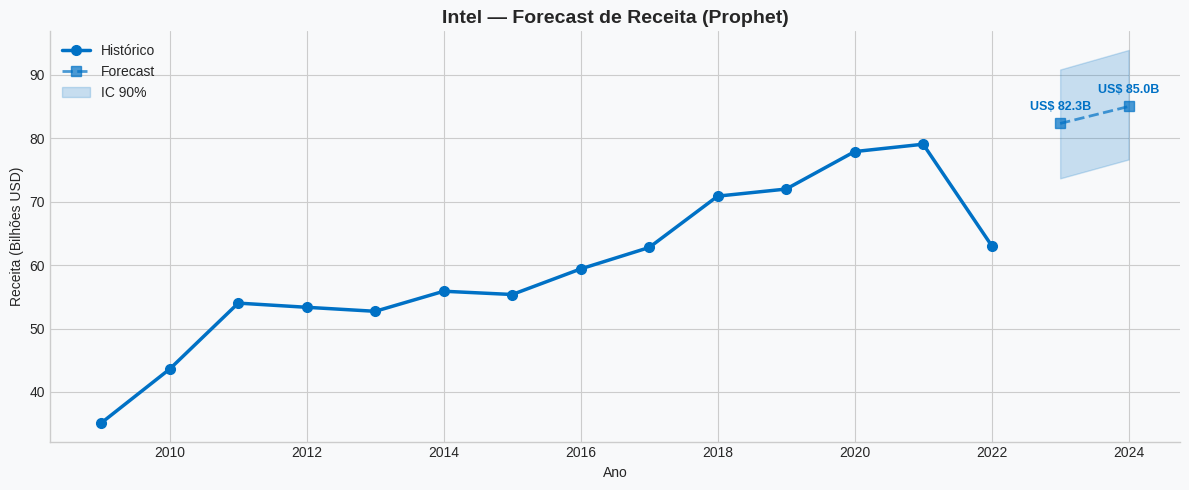

💾 forecast_intel.png salvo


In [21]:
# Forecast de Receita — NVIDIA com Prophet
def forecast_prophet(df_co, empresa, cor, anos_futuro=3):
    df_p = df_co[['Year', 'Revenue']].copy()
    df_p.columns = ['ds', 'y']
    df_p['ds'] = pd.to_datetime(df_p['ds'], format='%Y')

    model = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                    daily_seasonality=False, interval_width=0.90)
    model.fit(df_p)

    future  = model.make_future_dataframe(periods=anos_futuro, freq='YE')
    forecast = model.predict(future)

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    ax.plot(df_p['ds'].dt.year, df_p['y']/1000, 'o-', color=cor,
            linewidth=2.5, markersize=7, label='Histórico', zorder=5)

    future_only = forecast[forecast['ds'].dt.year > df_p['ds'].dt.year.max()]
    ax.plot(future_only['ds'].dt.year, future_only['yhat']/1000, 's--',
            color=cor, linewidth=2, markersize=7, alpha=0.7, label='Forecast')
    ax.fill_between(future_only['ds'].dt.year,
                    future_only['yhat_lower']/1000,
                    future_only['yhat_upper']/1000,
                    alpha=0.2, color=cor, label='IC 90%')

    for _, row in future_only.iterrows():
        ax.annotate(f"US$ {row['yhat']/1000:.1f}B",
                    xy=(row['ds'].year, row['yhat']/1000),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold', color=cor)

    ax.set_title(f'{empresa} — Forecast de Receita (Prophet)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Receita (Bilhões USD)')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fname = f'forecast_{empresa.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 {fname} salvo')

    return forecast

print('Calculando forecast NVIDIA...')
fc_nvda = forecast_prophet(nvda, 'NVIDIA', COR_NVDA)

print('\n Calculando forecast Intel...')
fc_intc = forecast_prophet(intc, 'Intel', COR_INTC)

**Clusterização das Empresas**

In [22]:
# Clusterização por perfil financeiro
features_cluster = ['Net Profit Margin', 'ROE', 'ROA', 'Revenue', 'Market Cap(in B USD)']
df_cluster = df.groupby('Company')[features_cluster].mean().dropna()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans   = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_cluster['Cluster'] = clusters

nomes_cluster = {}
for c in range(3):
    grupo = df_cluster[df_cluster['Cluster'] == c]
    media_margem = grupo['Net Profit Margin'].mean()
    if media_margem > 20:
        nomes_cluster[c] = 'Alta Eficiência'
    elif media_margem > 5:
        nomes_cluster[c] = 'Eficiência Moderada'
    else:
        nomes_cluster[c] = 'Baixa Eficiência'

df_cluster['Perfil'] = df_cluster['Cluster'].map(nomes_cluster)

print('Segmentação por perfil financeiro:')
print(df_cluster[['Net Profit Margin', 'ROE', 'ROA', 'Perfil']].round(1).sort_values('Net Profit Margin', ascending=False))

📊 Segmentação por perfil financeiro:
         Net Profit Margin    ROE   ROA               Perfil
Company                                                     
MSFT                 27.40  32.40 14.80  Eficiência Moderada
GOOG                 22.90  17.10 13.10  Eficiência Moderada
MCD                  22.70 -42.20 14.30      Alta Eficiência
AAPL                 22.50  61.30 19.10  Eficiência Moderada
INTC                 21.40  19.90 12.20      Alta Eficiência
NVDA                 17.50  19.10 12.30      Alta Eficiência
PYPL                 13.00  12.70  4.30     Baixa Eficiência
BCS                   8.30   5.00  0.20     Baixa Eficiência
AIG                   4.70   4.10  0.70     Baixa Eficiência
AMZN                  2.40  11.20  3.30  Eficiência Moderada
PCG                  -1.50  -8.80  0.00     Baixa Eficiência
SHLDQ                -3.50  16.70 -7.70     Baixa Eficiência


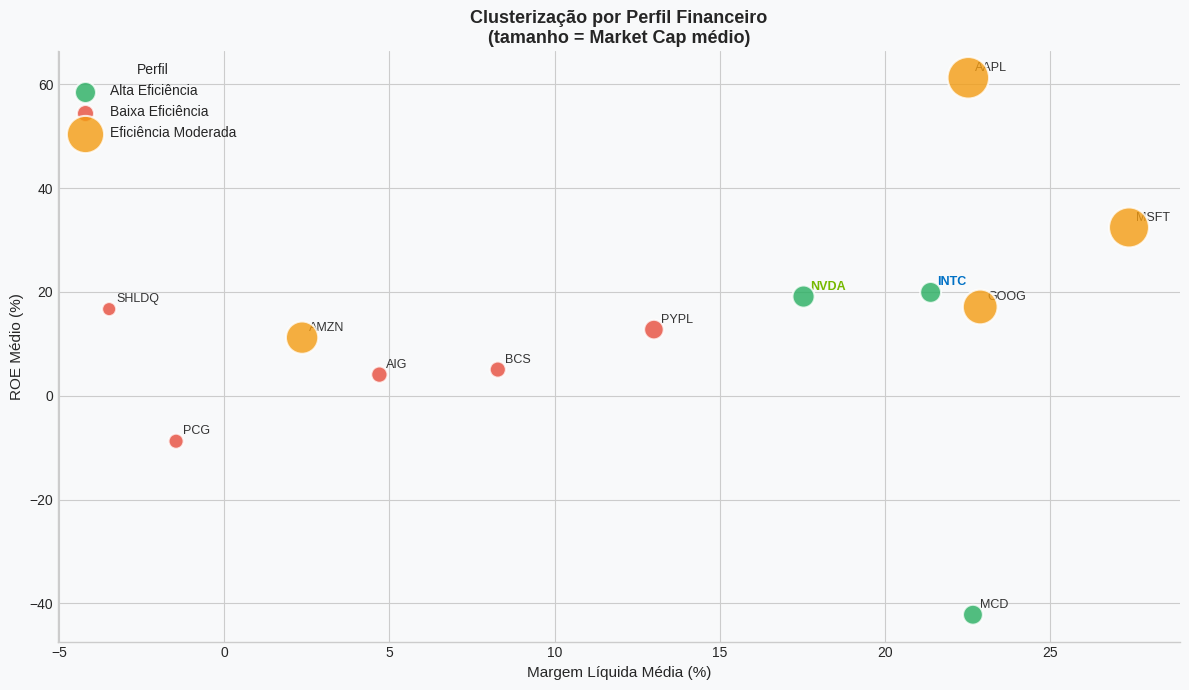

💾 clusters_empresas.png salvo


In [23]:
# Visualização dos clusters
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

cores_cluster = {'Alta Eficiência': '#27ae60', 'Eficiência Moderada': '#f39c12', 'Baixa Eficiência': '#e74c3c'}

for perfil, grupo in df_cluster.groupby('Perfil'):
    ax.scatter(grupo['Net Profit Margin'], grupo['ROE'],
               s=grupo['Market Cap(in B USD)'] * 0.8 + 100,
               color=cores_cluster[perfil], alpha=0.8,
               edgecolors='white', linewidth=1.5, label=perfil, zorder=5)
    for company, row in grupo.iterrows():
        cor_txt = COR_NVDA if company == 'NVDA' else COR_INTC if company == 'INTC' else '#333'
        peso = 'bold' if company in ['NVDA', 'INTC'] else 'normal'
        ax.annotate(company, xy=(row['Net Profit Margin'], row['ROE']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight=peso, color=cor_txt)

ax.set_xlabel('Margem Líquida Média (%)', fontsize=11)
ax.set_ylabel('ROE Médio (%)', fontsize=11)
ax.set_title('Clusterização por Perfil Financeiro\n(tamanho = Market Cap médio)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, title='Perfil', title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('clusters_empresas.png', dpi=150, bbox_inches='tight')
plt.show()
print('clusters_empresas.png salvo')

**Insights Finais**

In [25]:
ano_cruzamento = None
for ano in anos_comuns:
    mc_nvda = nvda_c[nvda_c['Year']==ano]['Market Cap(in B USD)'].values[0]
    mc_intc = intc_c[intc_c['Year']==ano]['Market Cap(in B USD)'].values[0]
    if mc_nvda > mc_intc and ano_cruzamento is None:
        ano_cruzamento = ano

mc_nvda_2009 = nvda_c[nvda_c['Year']==2009]['Market Cap(in B USD)'].values[0]
mc_intc_2009 = intc_c[intc_c['Year']==2009]['Market Cap(in B USD)'].values[0]
mc_nvda_last = nvda_c.iloc[-1]['Market Cap(in B USD)']
mc_intc_last = intc_c.iloc[-1]['Market Cap(in B USD)']

mult_nvda = mc_nvda_last / mc_nvda_2009
mult_intc = mc_intc_last / mc_intc_2009

print('-' * 65)
print('INSIGHTS FINAIS — NVIDIA vs INTEL (2009–2023)')
print('-' * 65)

print(f'''
1. INVERSÃO DE LIDERANÇA
   Em 2009 Intel tinha Market Cap {mc_intc_2009/mc_nvda_2009:.0f}x maior que NVIDIA.
   NVIDIA ultrapassou Intel em Market Cap pela primeira vez em {ano_cruzamento}.

2. CRESCIMENTO DE VALOR
   NVIDIA: Market Cap cresceu {mult_nvda:.0f}x em 14 anos
   Intel:  Market Cap cresceu apenas {mult_intc:.1f}x no mesmo período

3. EFICIÊNCIA OPERACIONAL
   Margem líquida média NVIDIA: {nvda_c["Net Profit Margin"].mean():.1f}%
   Margem líquida média Intel:  {intc_c["Net Profit Margin"].mean():.1f}%

4. O FATOR DETERMINANTE
   NVIDIA apostou em GPUs para IA e data centers a partir de 2016.
   A receita cresceu +{nvda_c[nvda_c["Year"]==2022]["Revenue_YoY"].values[0]:.0f}% em 2022 — o maior salto do dataset.
   Intel manteve foco em CPUs tradicionais e perdeu o ciclo de IA.

5. CLASSIFICAÇÃO FINAL (Clusterização)
   NVIDIA: {df_cluster.loc["NVDA", "Perfil"]}
   Intel:  {df_cluster.loc["INTC", "Perfil"]}
''')

-----------------------------------------------------------------
INSIGHTS FINAIS — NVIDIA vs INTEL (2009–2023)
-----------------------------------------------------------------

1. INVERSÃO DE LIDERANÇA
   Em 2009 Intel tinha Market Cap 11x maior que NVIDIA.
   NVIDIA ultrapassou Intel em Market Cap pela primeira vez em 2020.

2. CRESCIMENTO DE VALOR
   NVIDIA: Market Cap cresceu 35x em 14 anos
   Intel:  Market Cap cresceu apenas 1.0x no mesmo período

3. EFICIÊNCIA OPERACIONAL
   Margem líquida média NVIDIA: 17.6%
   Margem líquida média Intel:  21.4%

4. O FATOR DETERMINANTE
   NVIDIA apostou em GPUs para IA e data centers a partir de 2016.
   A receita cresceu +61% em 2022 — o maior salto do dataset.
   Intel manteve foco em CPUs tradicionais e perdeu o ciclo de IA.

5. CLASSIFICAÇÃO FINAL (Clusterização)
   NVIDIA: Alta Eficiência
   Intel:  Alta Eficiência

